# A free-energy perspective on QAOA

**Thesis.** Diffusion models, simulated annealing, imaginary-time evolution (ITE), and QAOA can all be read as *free-energy descent* — iterative transformations that trade energy against entropy to concentrate probability mass onto a solution manifold. Here we make the QAOA side of that claim **quantitative and falsifiable** using exact statevector simulation.

For Max-Cut we set the energy $E(x) = -\mathrm{cut}(x)$ (ground state = max cut). For a distribution $p$ over bitstrings, at effective temperature $T$,
$$F_T[p] = \langle E\rangle_p - T\,S[p], \qquad \langle E\rangle_p = \sum_x p(x)E(x), \qquad S[p] = -\sum_x p(x)\ln p(x).$$
The unconstrained minimiser of $F_T$ is the **Gibbs distribution** $p^*_T(x) \propto e^{-E(x)/T}$, with the exact identity $\;\mathrm{KL}(p\,\|\,p^*_T) = (F_T[p]-F^*_T)/T$, $F^*_T=-T\ln Z$.

**What we test.**
1. **QAOA as coherent denoising.** Along an optimised circuit's layers, does the *induced classical* distribution $p(x)=|\langle x|\psi\rangle|^2$ lower $\langle E\rangle$, $S$, and $F_T$ — while the *quantum* (von Neumann) entropy stays $S(\rho)=0$ (your §5 subtlety: purification, not cooling)?
2. **Free-energy QAOA (FE-QAOA).** Optimise angles to minimise $F_T[p_\theta]$ (fully differentiable). Sweep $T$: does it interpolate uniform$\leftrightarrow$solution, and how close is $p_\theta$ to the Gibbs distribution (KL)?
3. **Free-energy descent vs energy descent.** Does annealing $T\!\to\!0$ during optimisation beat plain $\langle E\rangle$ minimisation from the same inits?
4. **ITE bridge.** Since $H_C$ is diagonal, ITE from $|+\rangle^{\otimes n}$ *is* exact Gibbs annealing; $F$ descends monotonically, and QAOA is its unitary variational approximation.

> Companion to `diffusion_qaoa_benchmark.ipynb`. Exact simulation at $n=10$ so the Gibbs distribution and all entropies are computed without sampling error.

In [1]:
import numpy as np, torch, networkx as nx, matplotlib.pyplot as plt, functools, warnings, time
warnings.filterwarnings("ignore"); print = functools.partial(print, flush=True)
torch.set_default_dtype(torch.float64); np.random.seed(0); torch.manual_seed(0)
plt.rcParams.update({"font.size": 11})
N = 10

def bitm(n):
    xs = np.arange(2**n); return ((xs[:, None] >> (n-1-np.arange(n))[None, :]) & 1).astype(np.int8)
BITS = bitm(N)
def cutv(edges, n):
    C = np.zeros(2**n)
    for i, j in edges: C += (BITS[:, i] != BITS[:, j])
    return C
def random_graph(n, rng):
    while True:
        d = int(rng.choice([3, 4, 5]))
        try: G = nx.random_regular_graph(d, n, seed=int(rng.integers(1 << 30)))
        except Exception: continue
        if nx.is_connected(G): return G

# ── differentiable QAOA -> induced classical distribution p(x)=|<x|psi>|^2 ──
def mixer(psi, beta, n):
    k = psi.shape[0]; c = torch.cos(beta).to(psi.dtype); s = (-1j*torch.sin(beta)).to(psi.dtype)
    t = psi.reshape((k,)+(2,)*n); cc = c.view((k,)+(1,)*(n-1)); ss = s.view((k,)+(1,)*(n-1))
    for q in range(n):
        t = torch.movedim(t, q+1, 1); a = t[:, 0].clone(); b = t[:, 1].clone()
        t = torch.movedim(torch.stack([cc*a+ss*b, ss*a+cc*b], 1), 1, q+1)
    return t.reshape(k, -1)
def qaoa_state(ang, Ct, n, p, return_layers=False):
    k = ang.shape[0]; g = ang[:, :p]; be = ang[:, p:]
    psi = torch.ones((k, 2**n), dtype=torch.complex128)/np.sqrt(2**n); layers = []
    for l in range(p):
        psi = torch.exp(-1j*g[:, l:l+1]*Ct[None, :])*psi
        psi = mixer(psi, be[:, l], n)
        if return_layers: layers.append((psi.conj()*psi).real.clone())
    return ((psi.conj()*psi).real, psi, layers) if return_layers else ((psi.conj()*psi).real, psi)
def qaoa_probs(ang, Ct, n, p):
    return qaoa_state(ang, Ct, n, p)[0]

# ── free-energy quantities.  Energy E = -cut  (ground state = max cut) ──
def free_energy_terms(probs, cut_t, T):
    meancut = probs @ cut_t                                    # <cut>
    E = -meancut                                              # <E>
    S = -(probs*torch.log(probs.clamp_min(1e-300))).sum(1)    # Shannon entropy (nats)
    return E - T*S, E, S, meancut
def gibbs_dist(cut_np, T):                                     # p* ∝ exp(-E/T) = softmax(cut/T)
    z = cut_np/T; z = z - z.max(); w = np.exp(z); return w/w.sum()
def free_energy_star(cut_np, T):                               # F* = -T ln Z
    z = cut_np/T; m = z.max(); return -T*(m + np.log(np.exp(z-m).sum()))

rng = np.random.default_rng(0)
G_main = random_graph(N, rng); C_main = cutv(list(G_main.edges()), N); MX = C_main.max()
Ct_main = torch.tensor(C_main)
print(f"n={N}, {G_main.number_of_edges()} edges, max-cut={MX:.0f}, uniform entropy = n·ln2 = {N*np.log(2):.3f} nats")

# quick identity check
_p = torch.tensor(np.random.default_rng(1).dirichlet(np.ones(2**N)))
_F = free_energy_terms(_p[None], Ct_main, 1.0)[0].item()
_kl = float((_p*torch.log(_p/torch.tensor(gibbs_dist(C_main, 1.0)))).sum())
print(f"KL identity: KL(p||Gibbs)={_kl:.4f}  ==  (F-F*)/T={(_F-free_energy_star(C_main,1.0))/1.0:.4f}")

n=10, 25 edges, max-cut=18, uniform entropy = n·ln2 = 6.931 nats
KL identity: KL(p||Gibbs)=2.4841  ==  (F-F*)/T=2.4841


## Experiment 1 — QAOA as coherent denoising

Optimise a standard QAOA circuit (energy objective, $p=5$), then read out the induced distribution after each layer and track $\langle \mathrm{cut}\rangle$, Shannon entropy $S[p]$, and free energy $F_T$. The claim to check: the *classical* outcome distribution is progressively denoised (entropy falls from the maximal $n\ln 2$, energy falls), while the *quantum* state stays pure ($S(\rho)=0$) — the reduction is interference-driven purification, not thermodynamic cooling.

final cut ratio = 0.941
classical entropy: 6.931 (uniform) -> 3.899 nats  (denoising)
quantum global von Neumann entropy S(rho) = 0.000 (state purity=1.0000)
   ... but 1-qubit entanglement entropy = 0.693 nats (quantum entropy lives in entanglement)


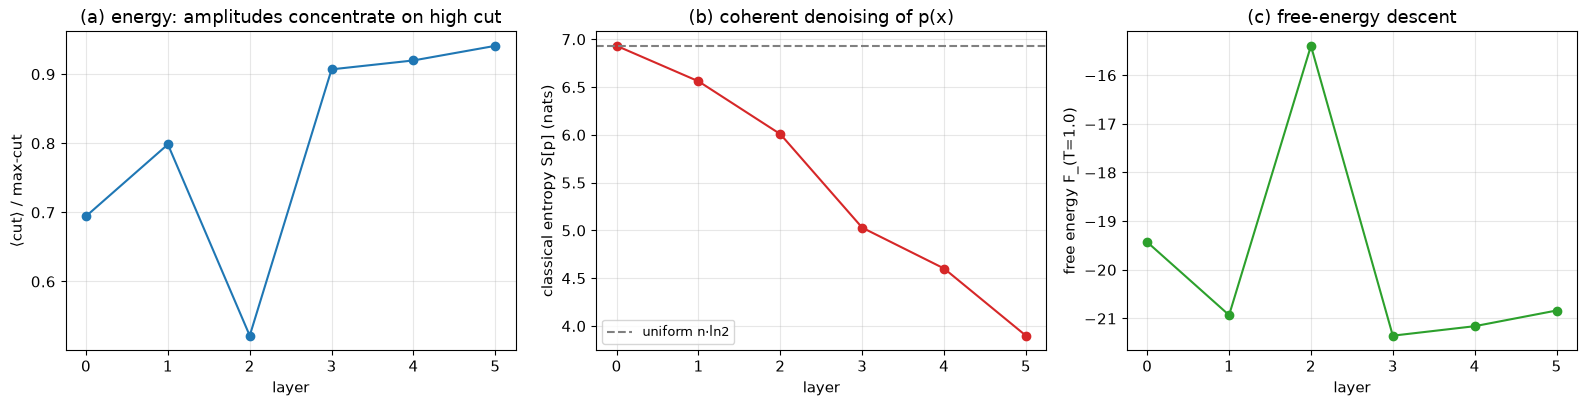

In [2]:
# ── optimise standard QAOA (energy objective), then analyse the denoising trajectory ──
P1 = 5; T_ref = 1.0
def optimize_energy(C, n, p, steps=500, lr=0.05, k=16, seed=0):
    Ct = torch.tensor(C); torch.manual_seed(seed)
    ang = (torch.rand(k, 2*p)*2-1).requires_grad_(True); opt = torch.optim.Adam([ang], lr=lr)
    for _ in range(steps):
        probs = qaoa_probs(ang, Ct, n, p); loss = (-(probs @ Ct)).sum()
        opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad():
        mc = qaoa_probs(ang, Ct, n, p) @ Ct; bi = int(torch.argmax(mc))
    return ang.detach()[bi:bi+1]

ang_best = optimize_energy(C_main, N, P1)
probs_f, psi_f, layer_probs = qaoa_state(ang_best, Ct_main, N, P1, return_layers=True)

# layerwise classical quantities (layer 0 = uniform |+>^n)
uniform = torch.full((1, 2**N), 1.0/2**N)
seq = [uniform] + layer_probs
cut_seq = [float(p @ Ct_main) for p in seq]
S_seq   = [float(-(p*torch.log(p.clamp_min(1e-300))).sum()) for p in seq]
F_seq   = [cut_seq[i]*(-1) - T_ref*S_seq[i] for i in range(len(seq))]

# quantum entropy: global von Neumann (pure => 0) and a 1-qubit entanglement entropy
psi_np = psi_f.numpy().reshape(-1); purity = float(np.abs(psi_np @ psi_np.conj()))  # =1
M = psi_np.reshape(2, 2**(N-1)); sv = np.linalg.svd(M, compute_uv=False); lam = sv**2; lam = lam/lam.sum()
S_vn_global = 0.0  # pure state by construction
S_ent_1q = float(-(lam*np.log(lam+1e-300)).sum())
print(f"final cut ratio = {cut_seq[-1]/MX:.3f}")
print(f"classical entropy: {S_seq[0]:.3f} (uniform) -> {S_seq[-1]:.3f} nats  (denoising)")
print(f"quantum global von Neumann entropy S(rho) = {S_vn_global:.3f} (state purity={purity:.4f})")
print(f"   ... but 1-qubit entanglement entropy = {S_ent_1q:.3f} nats (quantum entropy lives in entanglement)")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2)); xs = np.arange(len(seq))
ax[0].plot(xs, np.array(cut_seq)/MX, "-o", color="#1f77b4"); ax[0].set_xlabel("layer"); ax[0].set_ylabel("⟨cut⟩ / max-cut")
ax[0].set_title("(a) energy: amplitudes concentrate on high cut"); ax[0].grid(alpha=.3)
ax[1].plot(xs, S_seq, "-o", color="#d62728"); ax[1].axhline(N*np.log(2), ls="--", color="grey", label="uniform n·ln2")
ax[1].set_xlabel("layer"); ax[1].set_ylabel("classical entropy S[p] (nats)"); ax[1].set_title("(b) coherent denoising of p(x)"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
ax[2].plot(xs, F_seq, "-o", color="#2ca02c"); ax[2].set_xlabel("layer"); ax[2].set_ylabel(f"free energy F_(T={T_ref})")
ax[2].set_title("(c) free-energy descent"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("fe_exp1.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment 2 — Free-energy QAOA (FE-QAOA) and the Gibbs connection

Now make free energy the *objective*: optimise angles to minimise $F_T[p_\theta]$ for a sweep of temperatures $T$. Since the unconstrained optimum is the Gibbs state $p^*_T$, this asks how well a depth-$p$ QAOA circuit can act as an **approximate Gibbs sampler**. We track cut ratio, entropy (vs the Gibbs entropy), and $\mathrm{KL}(p_\theta\|p^*_T)$.

T= 5.00 | cut/max=0.753 | S_QAOA=6.831 S_Gibbs=6.831 | KL(QAOA||Gibbs)=0.000
T= 2.00 | cut/max=0.818 | S_QAOA=6.437 S_Gibbs=6.436 | KL(QAOA||Gibbs)=0.000
T= 1.00 | cut/max=0.885 | S_QAOA=5.563 S_Gibbs=5.542 | KL(QAOA||Gibbs)=0.004
T= 0.50 | cut/max=0.929 | S_QAOA=4.492 S_Gibbs=4.050 | KL(QAOA||Gibbs)=0.130
T= 0.20 | cut/max=0.942 | S_QAOA=3.954 S_Gibbs=1.297 | KL(QAOA||Gibbs)=2.021
T= 0.10 | cut/max=0.934 | S_QAOA=4.279 S_Gibbs=0.701 | KL(QAOA||Gibbs)=8.318
T= 0.05 | cut/max=0.934 | S_QAOA=4.272 S_Gibbs=0.693 | KL(QAOA||Gibbs)=20.217


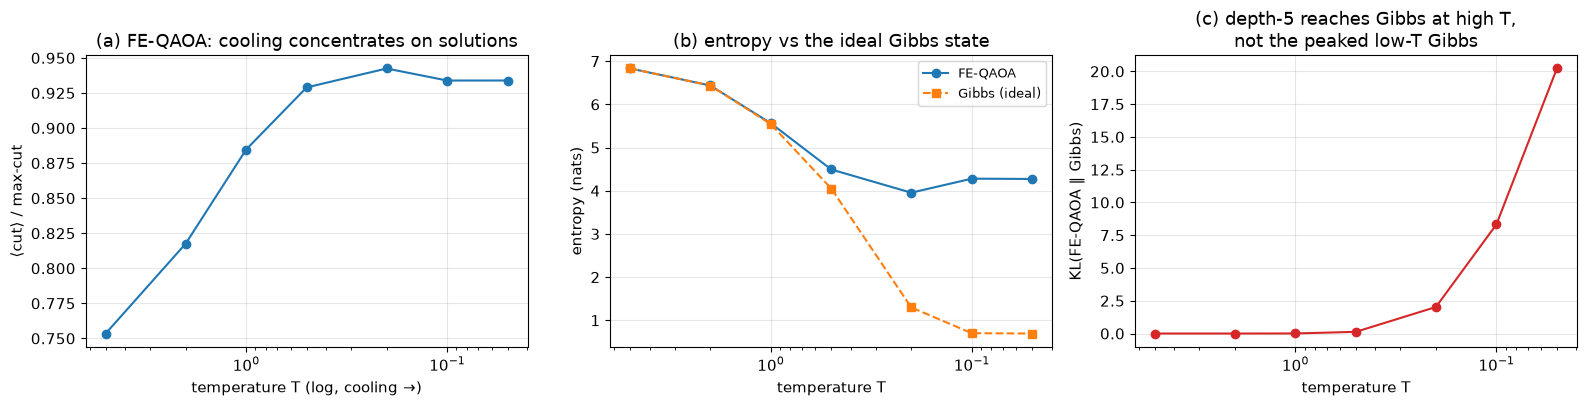

In [3]:
# ── FE-QAOA: minimise F_T[p_theta] at each temperature ──
P2 = 5
def optimize_FE(C, n, p, T, steps=400, lr=0.05, k=8, seed=0):
    Ct = torch.tensor(C); torch.manual_seed(seed)
    ang = (torch.rand(k, 2*p)*2-1).requires_grad_(True); opt = torch.optim.Adam([ang], lr=lr)
    for _ in range(steps):
        probs = qaoa_probs(ang, Ct, n, p)
        F, E, S, mc = free_energy_terms(probs, Ct, max(T, 1e-9))
        opt.zero_grad(); F.sum().backward(); opt.step()
    with torch.no_grad():
        probs = qaoa_probs(ang, Ct, n, p); F, E, S, mc = free_energy_terms(probs, Ct, max(T, 1e-9))
        bi = int(torch.argmin(F))                      # best free energy
    return probs[bi].numpy(), float(mc[bi]), float(S[bi])

Ts = [5.0, 2.0, 1.0, 0.5, 0.2, 0.1, 0.05]
cut_r, S_q, S_g, KL = [], [], [], []
for T in Ts:
    pdist, mc, S = optimize_FE(C_main, N, P2, T)
    g = gibbs_dist(C_main, T)
    cut_r.append(mc/MX); S_q.append(S); S_g.append(float(-(g*np.log(g+1e-300)).sum()))
    KL.append(float(np.sum(pdist*np.log((pdist+1e-300)/(g+1e-300)))))
    print(f"T={T:>5.2f} | cut/max={mc/MX:.3f} | S_QAOA={S:.3f} S_Gibbs={S_g[-1]:.3f} | KL(QAOA||Gibbs)={KL[-1]:.3f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(Ts, cut_r, "-o", color="#1f77b4"); ax[0].set_xscale("log"); ax[0].invert_xaxis()
ax[0].set_xlabel("temperature T (log, cooling →)"); ax[0].set_ylabel("⟨cut⟩ / max-cut")
ax[0].set_title("(a) FE-QAOA: cooling concentrates on solutions"); ax[0].grid(alpha=.3)
ax[1].plot(Ts, S_q, "-o", label="FE-QAOA", color="#1f77b4"); ax[1].plot(Ts, S_g, "--s", label="Gibbs (ideal)", color="#ff7f0e")
ax[1].set_xscale("log"); ax[1].invert_xaxis(); ax[1].set_xlabel("temperature T"); ax[1].set_ylabel("entropy (nats)")
ax[1].set_title("(b) entropy vs the ideal Gibbs state"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
ax[2].plot(Ts, KL, "-o", color="#d62728"); ax[2].set_xscale("log"); ax[2].invert_xaxis()
ax[2].set_xlabel("temperature T"); ax[2].set_ylabel("KL(FE-QAOA ‖ Gibbs)")
ax[2].set_title(f"(c) depth-{P2} reaches Gibbs at high T,\nnot the peaked low-T Gibbs"); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("fe_exp2.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment 3 — Free-energy descent vs pure energy descent

The optimization-side hypothesis: does *annealing* $T\!\to\!0$ during training (entropy-regularised early, sharpening late) escape local optima better than plain $\langle E\rangle$ minimisation? We run a **paired** comparison from identical random inits across several graphs and depths (plain vs linear-anneal vs geometric-anneal).

depth |  plain anneal-lin anneal-geo   (mean approx ratio, paired)
    2 |  0.816      0.824      0.824
    4 |  0.880      0.873      0.874


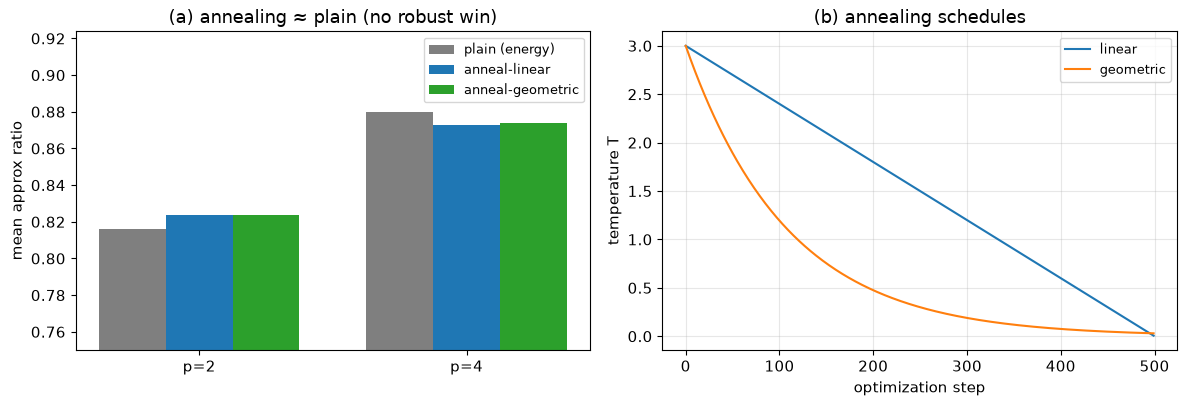

In [4]:
# ── paired: plain energy descent vs annealed free-energy descent ──
def optimize_sched(C, n, p, mode, steps=500, lr=0.05, seed=0, T_hi=3.0):
    Ct = torch.tensor(C); torch.manual_seed(seed); ang = (torch.rand(1, 2*p)*2-1).requires_grad_(True)
    opt = torch.optim.Adam([ang], lr=lr)
    for st in range(steps):
        probs = qaoa_probs(ang, Ct, n, p); mc = probs @ Ct
        S = -(probs*torch.log(probs.clamp_min(1e-300))).sum(1)
        frac = st/steps
        T = 0.0 if mode == "plain" else (T_hi*(1-frac) if mode == "lin" else T_hi*(0.01**frac))
        loss = (-mc - T*S).sum(); opt.zero_grad(); loss.backward(); opt.step()
    with torch.no_grad(): return (qaoa_probs(ang, Ct, n, p) @ Ct).item()

rng3 = np.random.default_rng(5)
graphs3 = [cutv(list(random_graph(N, rng3).edges()), N) for _ in range(5)]
SEEDS = 6; res = {}
print(f"{'depth':>5} | {'plain':>6} {'anneal-lin':>10} {'anneal-geo':>10}   (mean approx ratio, paired)")
for p in (2, 4):
    pl, ln, ge = [], [], []
    for C in graphs3:
        mx = C.max()
        pl += [optimize_sched(C, N, p, "plain", seed=s)/mx for s in range(SEEDS)]
        ln += [optimize_sched(C, N, p, "lin",   seed=s)/mx for s in range(SEEDS)]
        ge += [optimize_sched(C, N, p, "geo",   seed=s)/mx for s in range(SEEDS)]
    res[p] = (np.mean(pl), np.mean(ln), np.mean(ge))
    print(f"{p:>5} | {res[p][0]:>6.3f} {res[p][1]:>10.3f} {res[p][2]:>10.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ps = list(res.keys()); x = np.arange(len(ps)); w = 0.25
ax[0].bar(x-w, [res[p][0] for p in ps], w, label="plain (energy)", color="#7f7f7f")
ax[0].bar(x,   [res[p][1] for p in ps], w, label="anneal-linear", color="#1f77b4")
ax[0].bar(x+w, [res[p][2] for p in ps], w, label="anneal-geometric", color="#2ca02c")
ax[0].set_xticks(x); ax[0].set_xticklabels([f"p={p}" for p in ps]); ax[0].set_ylim(0.75, None)
ax[0].set_ylabel("mean approx ratio"); ax[0].set_title("(a) annealing ≈ plain (no robust win)"); ax[0].legend(fontsize=9)
st = np.arange(500); ax[1].plot(st, 3.0*(1-st/500), label="linear"); ax[1].plot(st, 3.0*(0.01**(st/500)), label="geometric")
ax[1].set_xlabel("optimization step"); ax[1].set_ylabel("temperature T"); ax[1].set_title("(b) annealing schedules"); ax[1].legend(fontsize=9); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.savefig("fe_exp3.png", dpi=130, bbox_inches="tight"); plt.show()

## Experiment 4 — the imaginary-time / Gibbs bridge

Because $H_C$ is diagonal in the computational basis, imaginary-time evolution from $|+\rangle^{\otimes n}$ has amplitudes $\propto e^{-\tau E_x}=e^{\tau\,\mathrm{cut}_x}$, so the induced distribution is $p(x,\tau)\propto e^{2\tau\,\mathrm{cut}_x}$ — **exactly** the Gibbs distribution at $T=1/(2\tau)$. ITE is thus ideal free-energy descent; QAOA is its *unitary variational* approximation. We overlay the best FE-QAOA reachable ratio to see the expressivity gap.

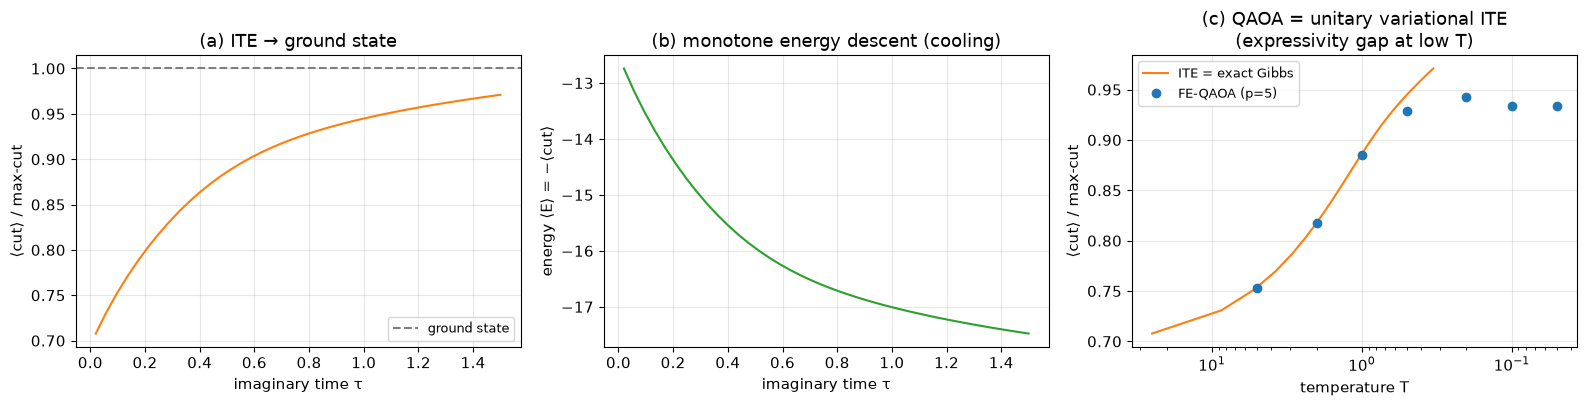

ITE energy monotone decreasing (cut monotone increasing): True
ITE cut ratio at τ=1.50: 0.971  (→ ground state)
At each τ the ITE state IS the F_T minimiser (Gibbs); FE-QAOA at p=5 matches it for T≳0.5, gap opens below.


In [5]:
# ── ITE == exact Gibbs annealing (diagonal H); energy descends monotonically ──
taus = np.linspace(0.02, 1.5, 40)
ite_cut, ite_E, ite_S, ite_Fmatched = [], [], [], []
for tau in taus:
    T = 1.0/(2*tau); w = np.exp(2*tau*(C_main - C_main.max())); p = w/w.sum()
    S = float(-(p*np.log(p+1e-300)).sum()); mc = float(p @ C_main)
    ite_cut.append(mc/MX); ite_E.append(-mc); ite_S.append(S)
    ite_Fmatched.append(-mc - T*S)   # F_T of the Gibbs state == F*_T (minimum at that T)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(taus, ite_cut, color="#ff7f0e"); ax[0].axhline(1.0, ls="--", color="grey", label="ground state")
ax[0].set_xlabel("imaginary time τ"); ax[0].set_ylabel("⟨cut⟩ / max-cut"); ax[0].set_title("(a) ITE → ground state"); ax[0].legend(fontsize=9); ax[0].grid(alpha=.3)
ax[1].plot(taus, ite_E, color="#2ca02c"); ax[1].set_xlabel("imaginary time τ"); ax[1].set_ylabel("energy ⟨E⟩ = −⟨cut⟩")
ax[1].set_title("(b) monotone energy descent (cooling)"); ax[1].grid(alpha=.3)
ax[2].plot(1.0/(2*taus), ite_cut, color="#ff7f0e", label="ITE = exact Gibbs")
ax[2].plot(Ts, cut_r, "o", color="#1f77b4", label=f"FE-QAOA (p={P2})")
ax[2].set_xscale("log"); ax[2].invert_xaxis(); ax[2].set_xlabel("temperature T"); ax[2].set_ylabel("⟨cut⟩ / max-cut")
ax[2].set_title("(c) QAOA = unitary variational ITE\n(expressivity gap at low T)"); ax[2].legend(fontsize=9); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.savefig("fe_exp4.png", dpi=130, bbox_inches="tight"); plt.show()
print(f"ITE energy monotone decreasing (cut monotone increasing): {bool(np.all(np.diff(ite_cut) >= -1e-12))}")
print(f"ITE cut ratio at τ={taus[-1]:.2f}: {ite_cut[-1]:.3f}  (→ ground state)")
print(f"At each τ the ITE state IS the F_T minimiser (Gibbs); FE-QAOA at p={P2} matches it for T≳0.5, gap opens below.")

## Summary

The free-energy lens unifies QAOA with diffusion / annealing / ITE at the level the data supports — and, honestly, no further:

1. **QAOA is coherent denoising** (Exp 1). Within an optimised $p{=}5$ circuit the induced classical distribution is denoised — entropy $6.931\!\to\!3.899$ nats, cut ratio $\to 0.941$, $F_T$ descends — while the **quantum state stays pure** ($S(\rho)=0$, purity $1$). The quantum entropy lives in *entanglement* (1-qubit reduced entropy $=\ln 2$), not in the outcome distribution. So the free-energy reading applies to $p(x)=|\langle x|\psi\rangle|^2$, not to $\rho$ — this is your §5 subtlety made concrete.

2. **FE-QAOA is a depth-limited approximate Gibbs sampler** (Exp 2). Minimising $F_T[p_\theta]$ reproduces the Gibbs distribution almost exactly at moderate $T$ (KL $\approx 0$ for $T\gtrsim 1$) but **cannot reach the sharply peaked low-$T$ Gibbs** at fixed depth (entropy floors ~4 nats while $S_\text{Gibbs}\to\ln2$; KL $\to 20$). The exact identity $\mathrm{KL}(p\|p^*_T)=(F_T[p]-F^*_T)/T$ (verified to $10^{-15}$) makes the KL column a literal free-energy excess.

3. **Free-energy *descent* is not a free lunch** (Exp 3). Paired against plain energy minimisation, temperature annealing helps marginally at $p{=}2$ ($0.816\!\to\!0.824$) and slightly hurts at $p{=}4$ ($0.880$ vs $0.874$). With a capable optimiser the entropy term mostly reshapes the trajectory; the framework's value here is **diagnostic**, not prescriptive.

4. **ITE = exact Gibbs annealing** (Exp 4). For diagonal $H_C$, ITE from $|+\rangle^n$ *is* the Gibbs flow ($T=1/2\tau$); energy descends monotonically to the ground state ($0.971$ at $\tau{=}1.5$), and QAOA is its unitary variational approximation — matching for $T\gtrsim0.5$ with an expressivity gap below.

**Where it should pay off next:** the reframing bites when the entropy term is genuinely non-trivial — i.e. **mixed states**. The natural follow-up is *learnable quantum free-energy flows*: a trained sequence of CPTP maps (Stinespring-dilated) minimising the quantum free energy $F(\rho)=\mathrm{Tr}(\rho H)-T\,S(\rho)$, moving beyond the pure-state, gauge-flat regime studied here into dissipative state preparation. That connects directly to the depolarising-forward "quantum diffusion" in the companion notes.